In [150]:
import pandas as pd
import numpy as np
import json
import pickle
import os
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
import tf2onnx

warnings.filterwarnings('ignore')

# Configuration

In [151]:
# --- 1. CONFIGURATION ---
OUTPUT_DIR = '../../model_outputs/augmented'
DATASET_PATH = '../../dataset/augmented_dataset_sapi.csv'

# OUTPUT_DIR = '../../model_outputs/massive'
# DATASET_PATH = '../../dataset/massive_dataset_sapi_lstm.csv' 

# OUTPUT_DIR = '../../model_outputs'
# DATASET_PATH = '../../dataset/dataset_sapi_lstm.csv' 
WINDOW = 30
TARGET = 'jumlah_susu'

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"✅ Output folder ready: {OUTPUT_DIR}")

✅ Output folder ready: ../../model_outputs/augmented


# Data Prep

In [ ]:
# --- 2. DATA PREPARATION ---
# print("Current directory:", os.getcwd())
df = pd.read_csv(DATASET_PATH)

# ==========================================
# FILTERING ANOMALI (Membuang data kotor)
# ==========================================
jumlah_awal = len(df)

# 1. Filter Pakan yang tidak logis (< 20 kg)
df = df[df['volume_pakan'] >= 20].copy()

# # 2. Filter Sapi yang sedang Hamil (Masa Kering)
df = df[df['status_reproduksi'].str.lower() != 'hamil'].copy()

# # 3. BARU: Filter Susu = 0 (Buang jika susu 0 atau di bawah 1 liter)
df = df[df['jumlah_susu'] >= 1.0].copy()

jumlah_terhapus = jumlah_awal - len(df)
print(f"🧹 Membersihkan Anomali: {jumlah_terhapus} baris dihapus (Pakan < 20kg, Sapi Hamil, atau Susu 0).")
# ==========================================

# Drop columns not needed for the math, ignoring errors if they don't exist
DROP_COLS = ['nama_sapi', 'pemerahan_id', 'tgl_lahir', 'pemerah']
df = df.drop(columns=[c for c in DROP_COLS if c in df.columns], errors='ignore')

# Sort chronologically per cow
df['tgl_pemerahan'] = pd.to_datetime(df['tgl_pemerahan'], errors='coerce')
df = df.sort_values(['sapi_id', 'tgl_pemerahan']).reset_index(drop=True)
# Terapkan Rolling Average 5 hari untuk menghaluskan fluktuasi harian
df['jumlah_susu'] = df.groupby('sapi_id')['jumlah_susu'].transform(lambda x: x.rolling(window=10, min_periods=1).mean())

# Extract Time Features
df['bulan'] = df['tgl_pemerahan'].dt.month
df['hari_minggu'] = df['tgl_pemerahan'].dt.dayofweek
df['jam'] = df['tgl_pemerahan'].dt.hour

print(f"✅ Data bersih siap diproses: {len(df)} baris.")

🧹 Membersihkan Anomali: 22 baris dihapus (Pakan < 20kg, Sapi Hamil, atau Susu 0).
✅ Data bersih siap diproses: 1529 baris.


# Robust Encoding

In [163]:
CATEGORICAL_COLS = ['jenis_sapi', 'jenis_pakan', 'kondisi_sapi', 'status_reproduksi']
encoders = {}

for col in CATEGORICAL_COLS:
    le = LabelEncoder()
    
    df[col] = df[col].astype(str)
    df[col + '_enc'] = le.fit_transform(df[col])
    encoders[col] = le
    print(f"Encoded {col}: {list(le.classes_)}")

df_final = df.drop(columns=CATEGORICAL_COLS + ['tgl_pemerahan'])

Encoded jenis_sapi: ['Perah jenis FH', 'Perah perabakan FH', 'Perah peranakan FH', 'perah jenis FH', 'perah peranakan FH', 'sapi perah jenis FH']
Encoded jenis_pakan: ['Campuran', 'Konsentrat', 'Rumput']
Encoded kondisi_sapi: ['Sehat']
Encoded status_reproduksi: ['Hamil', 'Laktasi']


# LTSM Sequence (Windowing)

In [164]:
FEATURE_COLS = [c for c in df_final.columns if c not in [TARGET, 'sapi_id']]
n_features = len(FEATURE_COLS)

all_X, all_y = [], []

for cow_id, group in df_final.groupby('sapi_id'):
    group = group.reset_index(drop=True)
    if len(group) <= WINDOW:
        print(f"⚠️ Skipping cow {cow_id}: Only {len(group)} records (needs > {WINDOW})")
        continue # Skip cows that don't have enough history

    features = group[FEATURE_COLS].values.astype(float)
    target = group[TARGET].values.astype(float).reshape(-1, 1)

    for i in range(WINDOW, len(group)):
        all_X.append(features[i-WINDOW:i])
        all_y.append(target[i])

all_X = np.array(all_X, dtype=np.float32)
all_y = np.array(all_y, dtype=np.float32)

# --- SAFETY CHECK TO PREVENT CRASH ---
if len(all_X) == 0:
    raise ValueError(f"❌ Error: No sequences generated! The dataset is too small for a WINDOW size of {WINDOW}.")

print(f"Total sequences created: {len(all_X)}")
# Catatan: Bagian MinMaxScaler sudah dihapus dari cell ini dan dipindah ke Cell 5

Total sequences created: 1109


# Training

In [165]:
# ==========================================
# 1. SPLIT DATA TANPA SHUFFLE (Berkesinambungan)
# ==========================================
# test_size=0.2 berarti 80% data awal untuk train, 20% data akhir untuk test
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    all_X, all_y, 
    test_size=0.2, 
    shuffle=False # PENTING: Cegah acak waktu untuk Time-Series
)

# ==========================================
# 2. SCALING HANYA BERDASARKAN DATA TRAIN (Cegah Leakage)
# ==========================================
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# a. Fit dan Transform X_train
n_samples_train = X_train_raw.shape[0]
X_train_2d = X_train_raw.reshape(-1, n_features)
X_train_scaled = scaler_X.fit_transform(X_train_2d).reshape(n_samples_train, WINDOW, n_features)

# b. Transform X_test (TIDAK BOLEH FIT!)
n_samples_test = X_test_raw.shape[0]
X_test_2d = X_test_raw.reshape(-1, n_features)
X_test_scaled = scaler_X.transform(X_test_2d).reshape(n_samples_test, WINDOW, n_features)

# c. Scaling Target (y)
y_train_scaled = scaler_y.fit_transform(y_train_raw.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test_raw.reshape(-1, 1))

print("=" * 50)
print("📊 DATA SPLIT & SCALING SUMMARY")
print("=" * 50)
print(f"✅ Training set: X_train_scaled shape = {X_train_scaled.shape}")
print(f"✅ Training set: y_train_scaled shape = {y_train_scaled.shape}")
print(f"✅ Test set: X_test_scaled shape = {X_test_scaled.shape}")
print(f"✅ Test set: y_test_scaled shape = {y_test_scaled.shape}")
print(f"\n📈 Scaling Ranges:")
print(f"   X_train min: {scaler_X.data_min_}, max: {scaler_X.data_max_}")
print(f"   y_train min: {scaler_y.data_min_[0]:.2f}, max: {scaler_y.data_max_[0]:.2f}")
print(f"\n✔️ Ready for model training!")


📊 DATA SPLIT & SCALING SUMMARY
✅ Training set: X_train_scaled shape = (887, 30, 8)
✅ Training set: y_train_scaled shape = (887, 1)
✅ Test set: X_test_scaled shape = (222, 30, 8)
✅ Test set: y_test_scaled shape = (222, 1)

📈 Scaling Ranges:
   X_train min: [45.  1.  0.  0.  0.  0.  0.  0.], max: [56. 12.  6. 23.  5.  1.  0.  1.]
   y_train min: 0.00, max: 20.00

✔️ Ready for model training!


In [166]:


# ==========================================
# 3. PEMBUATAN MODEL & TRAINING
# ==========================================
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(WINDOW, n_features)),
    # tf.keras.layers.LSTM(64, return_sequences=True),
    # tf.keras.layers.Dropout(0.2),
    tf.keras.layers.LSTM(64, return_sequences=False),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='linear')
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
print("\n🚀 Training started...")

# validation_split=0.1 akan mengambil 10% data paling akhir dari X_train secara berurutan
history = model.fit(X_train_scaled, y_train_scaled, epochs=100, batch_size=16, validation_split=0.1, verbose=1)


🚀 Training started...
Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0965 - mae: 0.2354 - val_loss: 0.0782 - val_mae: 0.2147
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0453 - mae: 0.1493 - val_loss: 0.0734 - val_mae: 0.2134
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0437 - mae: 0.1407 - val_loss: 0.0766 - val_mae: 0.1994
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0443 - mae: 0.1425 - val_loss: 0.0756 - val_mae: 0.2064
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0428 - mae: 0.1373 - val_loss: 0.0798 - val_mae: 0.2088
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0403 - mae: 0.1309 - val_loss: 0.0759 - val_mae: 0.2042
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0388 - mae: 0.1318 - val_loss: 0.0818 - val_mae: 0.2006
Epoch 8/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0415 - mae: 0.1374 - val_loss: 0.0817 - val_mae: 0.2050
Epoch 9/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0

# Evaluating & Saving

In [167]:
# --- EVALUASI MODEL ---
# Gunakan X_test_scaled dan y_test_scaled yang sudah kita buat di Cell 5
y_pred = scaler_y.inverse_transform(model.predict(X_test_scaled))
y_true = scaler_y.inverse_transform(y_test_scaled)

print(f"\nFinal MAE: {mean_absolute_error(y_true, y_pred):.2f} Liter")

# --- EXPORT STANDARD TOOLS ---
with open(f'{OUTPUT_DIR}/scaler_X.pkl', 'wb') as f: pickle.dump(scaler_X, f)
with open(f'{OUTPUT_DIR}/scaler_y.pkl', 'wb') as f: pickle.dump(scaler_y, f)
with open(f'{OUTPUT_DIR}/encoders.pkl', 'wb') as f: pickle.dump(encoders, f)

# --- EXPORT JSON PARAMS (Untuk Android) ---
params = {
    "X_min": scaler_X.data_min_.tolist(), 
    "X_max": scaler_X.data_max_.tolist(),
    "y_min": float(scaler_y.data_min_[0]), 
    "y_max": float(scaler_y.data_max_[0]),
    "window": WINDOW, 
    "n_features": n_features,
    "feature_names": FEATURE_COLS,
    "categorical_encodings": {
        col: {str(k): int(v) for k, v in zip(le.classes_, le.transform(le.classes_))} 
        for col, le in encoders.items()
    }
}

with open(f'{OUTPUT_DIR}/scaler_params.json', 'w') as f: 
    json.dump(params, f, indent=2)

print("✅ Evaluasi selesai. Parameter Scaler (JSON & Pickle) berhasil disimpan!")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step

Final MAE: 3.48 Liter
✅ Evaluasi selesai. Parameter Scaler (JSON & Pickle) berhasil disimpan!


In [168]:
with open(f'{OUTPUT_DIR}/scaler_params.json', 'w') as f: json.dump(params, f, indent=2)

# Export ONNX (Robust Version)
functional_model = tf.keras.Model(inputs=model.inputs, outputs=model.outputs)
input_sig = [tf.TensorSpec(shape=[None, WINDOW, n_features], dtype=tf.float32, name='input')]

onnx_model, _ = tf2onnx.convert.from_keras(
    functional_model, 
    input_signature=input_sig, 
    opset=13
)

with open(f'{OUTPUT_DIR}/milk_lstm.onnx', 'wb') as f:
    f.write(onnx_model.SerializeToString())

print("✅ ONNX & JSON Params updated and ready for Android!")

✅ ONNX & JSON Params updated and ready for Android!


# Tflite model creation

In [169]:
with open(f'{OUTPUT_DIR}/scaler_params.json', 'w') as f: 
    json.dump(params, f, indent=2)

# --- EXPORT TO TFLITE (For Android) ---
# 1. Initialize the converter
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# --- 🚀 THE FIX FOR LSTM CONVERSION 🚀 ---
# Enable TensorFlow Select Ops to handle complex LSTM internal operations
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS, 
    tf.lite.OpsSet.SELECT_TF_OPS
]
# Disable lowering tensor list ops as requested by the compiler
converter._experimental_lower_tensor_list_ops = False
# -----------------------------------------

# 3. Convert the model
tflite_model = converter.convert()

# 4. Save it as a .tflite file
with open(f'{OUTPUT_DIR}/milk_lstm.tflite', 'wb') as f:
    f.write(tflite_model)

print(f"✅ milk_lstm.tflite & scaler_params.json are ready!")
print(f"📁 Find them in: {OUTPUT_DIR}")

INFO:tensorflow:Assets written to: C:\Users\nawfal\AppData\Local\Temp\tmpn_z67yuu\assets


INFO:tensorflow:Assets written to: C:\Users\nawfal\AppData\Local\Temp\tmpn_z67yuu\assets


Saved artifact at 'C:\Users\nawfal\AppData\Local\Temp\tmpn_z67yuu'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 30, 8), dtype=tf.float32, name='keras_tensor_84')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  1993378426800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1993378571616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1993378574432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1993378574256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1993378567920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1993378569504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1993378567392: TensorSpec(shape=(), dtype=tf.resource, name=None)
✅ milk_lstm.tflite & scaler_params.json are ready!
📁 Find them in: ../../model_outputs/augmented


# Test 

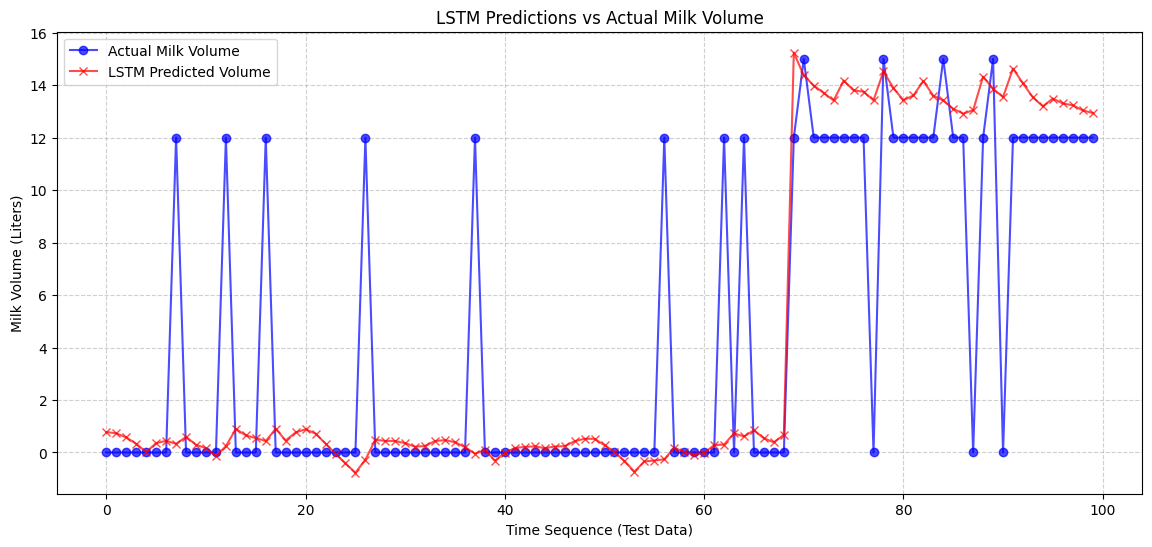

In [170]:
import matplotlib.pyplot as plt

# We plot only the first 100 sequences so the graph isn't too crowded
plt.figure(figsize=(14, 6))
plt.plot(y_true[:100], label="Actual Milk Volume", color='blue', marker='o', alpha=0.7)
plt.plot(y_pred[:100], label="LSTM Predicted Volume", color='red', marker='x', alpha=0.7)

plt.title("LSTM Predictions vs Actual Milk Volume")
plt.xlabel("Time Sequence (Test Data)")
plt.ylabel("Milk Volume (Liters)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [171]:
# --- CELL EVALUASI PERFORMA MODEL ---
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Menghitung R2 Score (Seberapa dekat dengan "sempurna"?)
# R2 = 1.0 berarti sempurna, 0.0 berarti model hanya menebak rata-rata
r2 = r2_score(y_true, y_pred)

# 2. Menghitung Persentase Error (MAPE - Mean Absolute Percentage Error)
# Ini memberi tahu kita: "Rata-rata prediksi meleset berapa persen dari target?"
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# 3. Menghitung Persentase Keberhasilan
success_rate = 100 - mape

print("=" * 50)
print("🎯 EVALUASI AKURASI MODEL")
print("=" * 50)
print(f"📊 R-Squared (Kedekatan ke Sempurna): {r2:.4f}")
print(f"📉 Mean Absolute Error (MAE): {mean_absolute_error(y_true, y_pred):.2f} Liter")
print(f"✅ Persentase Keberhasilan: {success_rate:.2f}%")

if r2 > 0.8:
    print("\n🌟 Prediksi Anda sangat akurat! Model sudah sangat bisa diandalkan.")
elif r2 > 0.6:
    print("\n✅ Prediksi sudah cukup baik untuk estimasi kasar.")
else:
    print("\n⚠️ Perlu perbaikan lebih lanjut pada data atau arsitektur model.")

🎯 EVALUASI AKURASI MODEL
📊 R-Squared (Kedekatan ke Sempurna): 0.5661
📉 Mean Absolute Error (MAE): 3.48 Liter
✅ Persentase Keberhasilan: -inf%

⚠️ Perlu perbaikan lebih lanjut pada data atau arsitektur model.
